## Hämtar in data och kikar lite 

In [1]:
import os
import pandas as pd

df = pd.read_csv('../data/historical_data.csv')
df = pd.DataFrame(df)

# Skriv ut de första 5 raderna för att dubbelkolla att det ser bra ut
df.head(10)

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0
5,5,11,message_send,phones,rural,android,31.9,6,0,2,502.33,5,247,0,0,0,26.3,0
6,6,6,message_send,electronics,rural,android,133.9,9,0,0,46.40,2,188,0,0,0,3.2,0
7,7,3,ad_post,other,metro,android,5.8,3,0,0,209.24,4,0,0,0,1,3.5,0
8,8,14,message_send,fashion,urban,web,38.7,4,0,0,41.47,2,135,0,0,1,14.6,0
9,9,1,message_send,other,rural,android,71.1,1,1,1,432.86,6,88,0,0,1,21.8,0


## Undersöker datan


In [2]:


print(df.shape)
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nRegion - because we have missing values:\n", df["region"].value_counts(dropna=False))
print("\nTime to first response - because we have missing values:\n", df["time_to_first_response_min"].value_counts(dropna=False))

print("\nTarget distribution\n", df["is_suspicious"].value_counts(normalize=True)) # Hur fördelningen av vår target "suspicious vs non sucpicious" ser ut




(12000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platfo

## Checkar numerisk information (medelvärde, minsta, max, varians etc)

In [3]:
df.describe()

target = "is_suspicious"

## Heatmap för de numeriska värdena 

4 variabler har en positiv korrelation med vår target "is_suspicious"

- contains_off_platform
- urgency_words
- payment_attempt
- prev_reports_30d

**Note**: Det som korrelerar negativt med vår target verkar vara account_age_days (desto längre ett konto funnits desto lägre sannolikhet att det utför bedrägrerier)


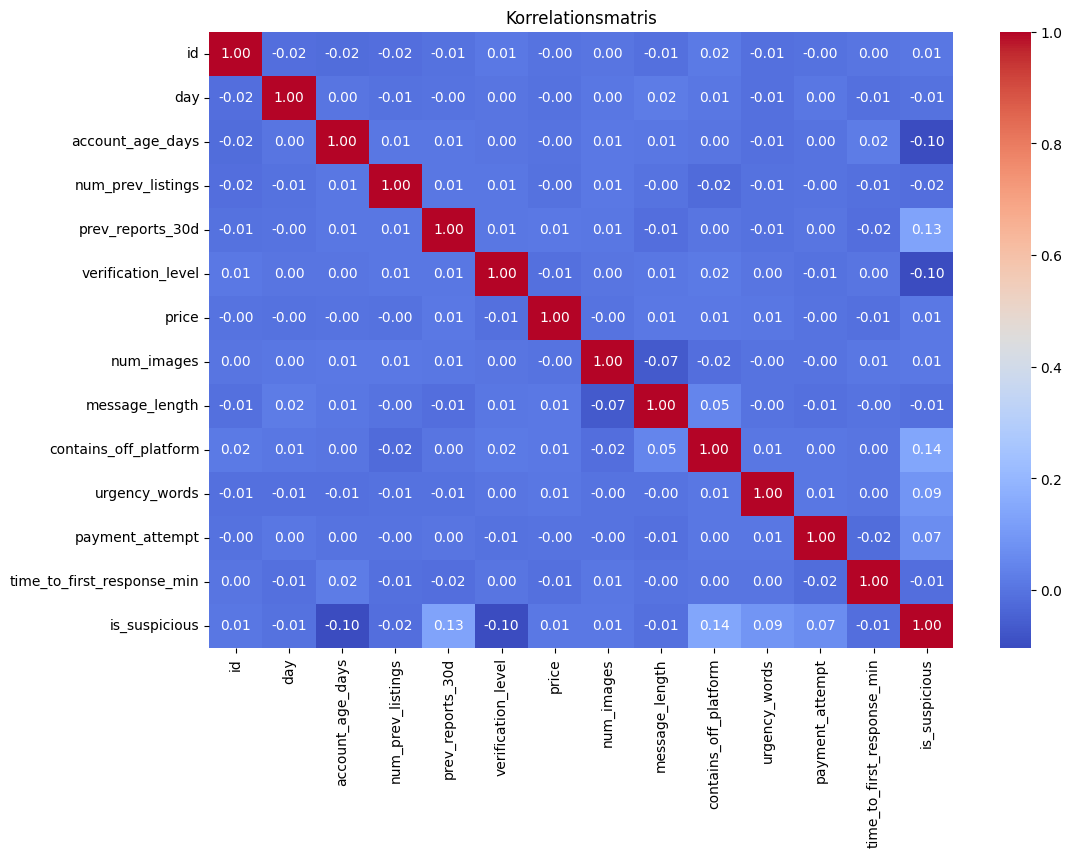

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korrelationsmatris')
plt.show()

### Kikar på hur många unika värden varje string kolumn innehar (hur många kategorier som finns i vardera)

För många unika värden gör string kolumnen svår att bruka, men här har vi mellan 2-6 unika värden vilket är mycket goda nyheter


In [5]:
# Kolla hur många unika kategorier varje sträng-kolumn har
string_cols = df.select_dtypes(include=['object', 'str']).columns

for col in string_cols:
    print(f"{col}: {df[col].nunique()} unika värden")

TypeError: numpy string dtypes are not allowed, use 'str' or 'object' instead

## Kikar på lite korrelationer med vår target

- Vi inser här att bland "account_age_days" så finns det en hel del outliers (förmodligen inaktiva konton). 
- Skickas en extern länk i kommunikationen mellan köpare/säljare så ökar sannolikheten att det är en bedragare

C:\Users\kaisa\AppData\Local\Temp\ipykernel_22908\1250110988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y='account_age_days', data=df, ax=axes[0], palette='Set2')
C:\Users\kaisa\AppData\Local\Temp\ipykernel_22908\1250110988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='contains_off_platform', y=target, data=df, ax=axes[1], palette='viridis')


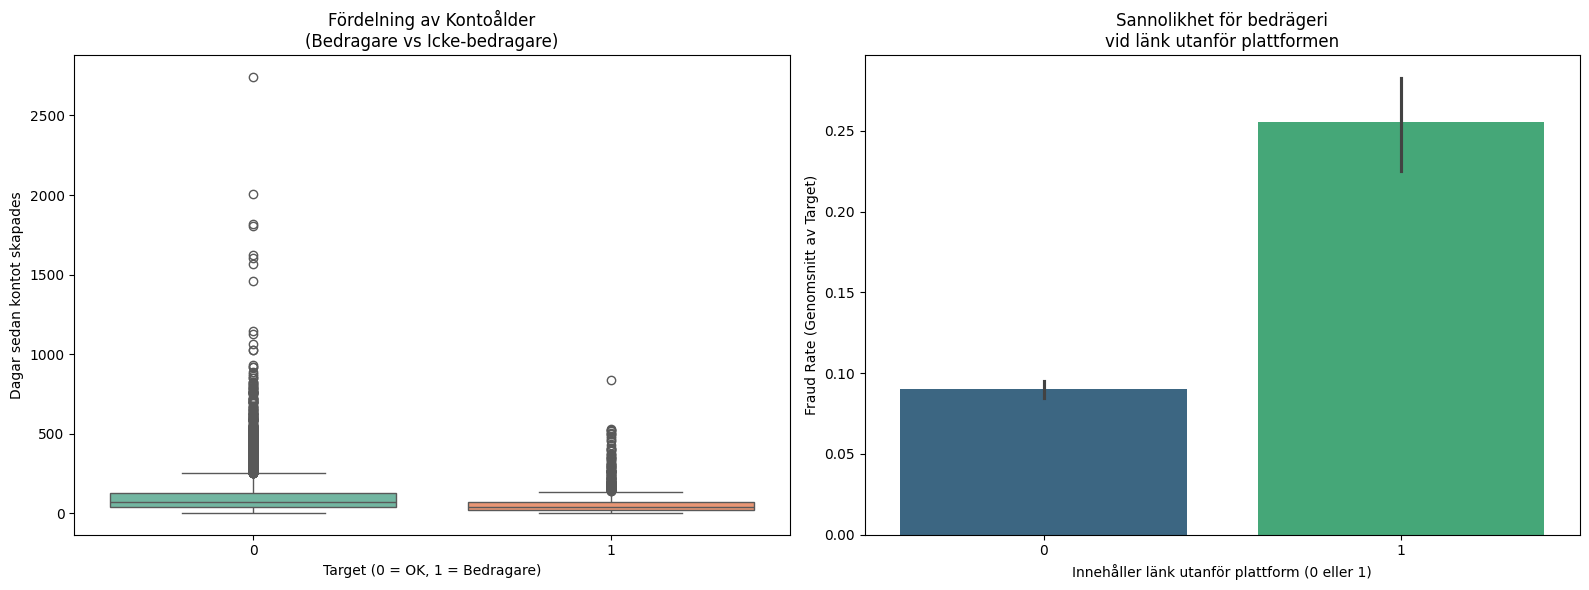

In [6]:
target = "is_suspicious"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Kontots ålder vs potentiellt bedrägeriförsök
sns.boxplot(x=target, y='account_age_days', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Fördelning av Kontoålder\n(Bedragare vs Icke-bedragare)')
axes[0].set_xlabel('Target (0 = OK, 1 = Bedragare)')
axes[0].set_ylabel('Dagar sedan kontot skapades')

# Plot 2 - Sannolikheten för bedrägeri baserat på om de har skickat en länk eller ej
sns.barplot(x='contains_off_platform', y=target, data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Sannolikhet för bedrägeri\nvid länk utanför plattformen')
axes[1].set_xlabel('Innehåller länk utanför plattform (0 eller 1)')
axes[1].set_ylabel('Fraud Rate (Genomsnitt av Target)')

plt.tight_layout()
plt.show()

## Train/test + preprocessing

**Att fånga så många verkligt misstänkta fall som möjligt.**
Alltså en binär klassificering:
- 1 = farligt / misstänkt 
- 0 = inte farligt
- `is_suspicious` = 1 → farligt fall
- `is_suspicious` = 0 → normalt fall

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [24]:
X = df.drop("is_suspicious", axis=1)
y = df["is_suspicious"]

if "id" in X.columns:
    X = X.drop(columns=["id"])

print(y.value_counts(normalize=True))

is_suspicious
0    0.898
1    0.102
Name: proportion, dtype: float64


In [19]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train proportion:\n", y_train.value_counts(normalize=True))
print("Test proportion:\n", y_test.value_counts(normalize=True))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train proportion:
 is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64
Test proportion:
 is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64
Train shape: (9600, 16)
Test shape: (2400, 16)


In [25]:
# Identifiera numeriska/kategoriska kolumner:

numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumerical:", numeric_features)
print("Categorical:", categorical_features)


Numerical: ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']
Categorical: ['event_type', 'category', 'region', 'device']


In [22]:
# Preprocessing pipelines

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 4) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ],
    remainder="drop"
)

In [23]:
# Pipeline (no leakage) - sanity check och fit endast på train:

pipeline_sanity = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED))
])

pipeline_sanity.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
